# LaporKeuangan — Head 2: Prediksi Arus Kas (MLP + GRU)
**Coding Camp 2026 · DBS Foundation · CC26-PSU098**

Head 2 memprediksi pengeluaran mahasiswa 7 hari ke depan
berdasarkan riwayat transaksi 30 hari sebelumnya.

### Arsitektur:
```
Input (30 hari × 8 kategori)
→ MLP Encoder per hari
→ GRU Layer 1 (64 units)
→ GRU Layer 2 (32 units)
→ Dense Decoder
→ Output (7 hari × 8 kategori)
```

### 8 Kategori:
`makanan` · `minuman` · `transportasi` · `belanja`
`tagihan` · `hiburan` · `kesehatan` · `lain_lain`


## Cell 1 — Install & Setup

In [1]:
!pip install tensorflow scikit-learn matplotlib numpy pandas -q

print("Instalasi selesai.")

Instalasi selesai.


## Cell 2 — Import & Konfigurasi

In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Kategori pengeluaran mahasiswa
CATEGORIES = [
    'makanan', 'minuman', 'transportasi', 'belanja',
    'tagihan', 'hiburan', 'kesehatan', 'lain_lain'
]
N_CATS    = len(CATEGORIES)
CAT_IDX   = {c: i for i, c in enumerate(CATEGORIES)}

# Warna per kategori untuk visualisasi
CAT_COLORS = {
    'makanan'      : '#2ECC71',
    'minuman'      : '#3498DB',
    'transportasi' : '#E67E22',
    'belanja'      : '#9B59B6',
    'tagihan'      : '#E74C3C',
    'hiburan'      : '#F39C12',
    'kesehatan'    : '#1ABC9C',
    'lain_lain'    : '#95A5A6',
}

print(f"Kategori ({N_CATS}): {CATEGORIES}")
print(f"TF version: {tf.__version__}")

Kategori (8): ['makanan', 'minuman', 'transportasi', 'belanja', 'tagihan', 'hiburan', 'kesehatan', 'lain_lain']
TF version: 2.19.0


## Cell 3 — Generate Dataset Sintetis

In [3]:
def generate_head2_dataset_v2(
    n_users=150, n_days=90, seed=42
):
    """
    Dataset sintetis Head 2 yang lebih representatif.

    Perbedaan dari versi lama:
    - Tagihan: spike di awal bulan (tgl 1-5), sisa hari = 0
    - Hiburan: hanya weekend (Sabtu-Minggu) + sesekali weekday
    - Kesehatan: sporadis acak, jarang (2-3x sebulan)
    - Belanja: spike acak 1-3x seminggu
    - Makanan/minuman/transportasi: harian dengan variasi
    """
    rng = np.random.RandomState(seed)

    # Budget rata-rata mahasiswa per hari (ribuan Rp)
    DAILY_BUDGET = {
        'makanan'      : 35,   # harian rutin
        'minuman'      : 18,   # harian rutin
        'transportasi' : 20,   # harian rutin
        'belanja'      : 15,   # beberapa kali seminggu
        'tagihan'      : 10,   # awal bulan saja
        'hiburan'      : 8,    # weekend saja
        'kesehatan'    : 5,    # sporadis
        'lain_lain'    : 8,    # acak
    }

    all_X, all_y = [], []

    for user in range(n_users):
        # Profil user: hemat/normal/boros
        r = rng.random()
        if r < 0.25:   mult = rng.uniform(0.4, 0.7)   # hemat
        elif r < 0.75: mult = rng.uniform(0.7, 1.1)   # normal
        else:          mult = rng.uniform(1.1, 1.6)   # boros

        # Generate 90 hari pengeluaran
        daily = {cat: np.zeros(n_days) for cat in CATEGORIES}

        for day in range(n_days):
            day_of_month = (day % 30) + 1
            day_of_week  = day % 7  # 0=Senin, 5=Sabtu, 6=Minggu

            # ── MAKANAN: harian, selalu ada ──────────────────────
            base = DAILY_BUDGET['makanan'] * mult
            daily['makanan'][day] = max(0, base * rng.uniform(0.7, 1.4))

            # ── MINUMAN: harian, 80% chance ──────────────────────
            if rng.random() < 0.80:
                base = DAILY_BUDGET['minuman'] * mult
                daily['minuman'][day] = max(0, base * rng.uniform(0.5, 1.5))

            # ── TRANSPORTASI: harian weekday, jarang weekend ──────
            if day_of_week < 5:   # weekday
                if rng.random() < 0.85:
                    base = DAILY_BUDGET['transportasi'] * mult
                    daily['transportasi'][day] = max(0, base * rng.uniform(0.6, 1.4))
            else:  # weekend
                if rng.random() < 0.40:
                    base = DAILY_BUDGET['transportasi'] * mult
                    daily['transportasi'][day] = max(0, base * rng.uniform(0.5, 1.2))

            # ── BELANJA: 2-3x seminggu, tidak tentu ──────────────
            if rng.random() < 0.35:
                base = DAILY_BUDGET['belanja'] * mult * rng.uniform(2, 8)
                daily['belanja'][day] = max(0, base * rng.uniform(0.5, 2.0))

            # ── TAGIHAN: SPIKE di awal bulan (tgl 1-7) ───────────
            if day_of_month <= 7:
                if rng.random() < 0.40:  # 40% chance tiap hari di awal bulan
                    # Bayar tagihan besar sekaligus
                    spike = rng.uniform(50, 300) * mult
                    daily['tagihan'][day] = spike
            elif day_of_month <= 15:
                if rng.random() < 0.05:  # sangat jarang di pertengahan
                    daily['tagihan'][day] = rng.uniform(20, 80) * mult
            # sisa bulan: 0

            # ── HIBURAN: weekend lebih sering, weekday jarang ─────
            if day_of_week >= 5:  # Sabtu-Minggu
                if rng.random() < 0.55:
                    base = DAILY_BUDGET['hiburan'] * mult * rng.uniform(2, 6)
                    daily['hiburan'][day] = max(0, base)
            else:  # weekday
                if rng.random() < 0.10:
                    base = DAILY_BUDGET['hiburan'] * mult * rng.uniform(1, 3)
                    daily['hiburan'][day] = max(0, base)

            # ── KESEHATAN: sporadis, 2-4x sebulan ────────────────
            if rng.random() < 0.08:  # ~8% per hari = ~2-3x sebulan
                spike = rng.uniform(15, 150) * mult
                daily['kesehatan'][day] = spike

            # ── LAIN_LAIN: acak, beberapa kali seminggu ──────────
            if rng.random() < 0.25:
                base = DAILY_BUDGET['lain_lain'] * mult * rng.uniform(1, 4)
                daily['lain_lain'][day] = max(0, base)

        # Build sequences: input 30 hari → target 7 hari
        for start in range(n_days - 30 - 7 + 1):
            X_seq = np.array([
                [daily[cat][start+d] for cat in CATEGORIES]
                for d in range(30)
            ], dtype=np.float32)  # shape: (30, 8)

            y_seq = np.array([
                [daily[cat][start+30+d] for cat in CATEGORIES]
                for d in range(7)
            ], dtype=np.float32)  # shape: (7, 8)

            all_X.append(X_seq)
            all_y.append(y_seq)

    return np.array(all_X), np.array(all_y)


# Test generate
print("Generating dataset Head 2 v2...")
X_h2, y_h2 = generate_head2_dataset_v2(n_users=150, n_days=90)
print(f"Shape X: {X_h2.shape}")  # (n_samples, 30, 8)
print(f"Shape y: {y_h2.shape}")  # (n_samples, 7, 8)

# Cek distribusi per kategori
print("\nRata-rata pengeluaran harian per kategori:")
for i, cat in enumerate(CATEGORIES):
    mean_val = X_h2[:, :, i].mean()
    zero_pct = (X_h2[:, :, i] == 0).mean() * 100
    print(f"  {cat:<15}: mean={mean_val:6.1f}rb | zero={zero_pct:.1f}%")

Generating dataset Head 2 v2...
Shape X: (8100, 30, 8)
Shape y: (8100, 7, 8)

Rata-rata pengeluaran harian per kategori:
  makanan        : mean=  33.9rb | zero=0.0%
  minuman        : mean=  13.3rb | zero=20.5%
  transportasi   : mean=  13.1rb | zero=27.6%
  belanja        : mean=  30.3rb | zero=64.7%
  tagihan        : mean=  14.9rb | zero=89.6%
  hiburan        : mean=   5.7rb | zero=76.9%
  kesehatan      : mean=   6.1rb | zero=92.0%
  lain_lain      : mean=   4.7rb | zero=75.1%


## Cell 4 — Eksplorasi & Visualisasi

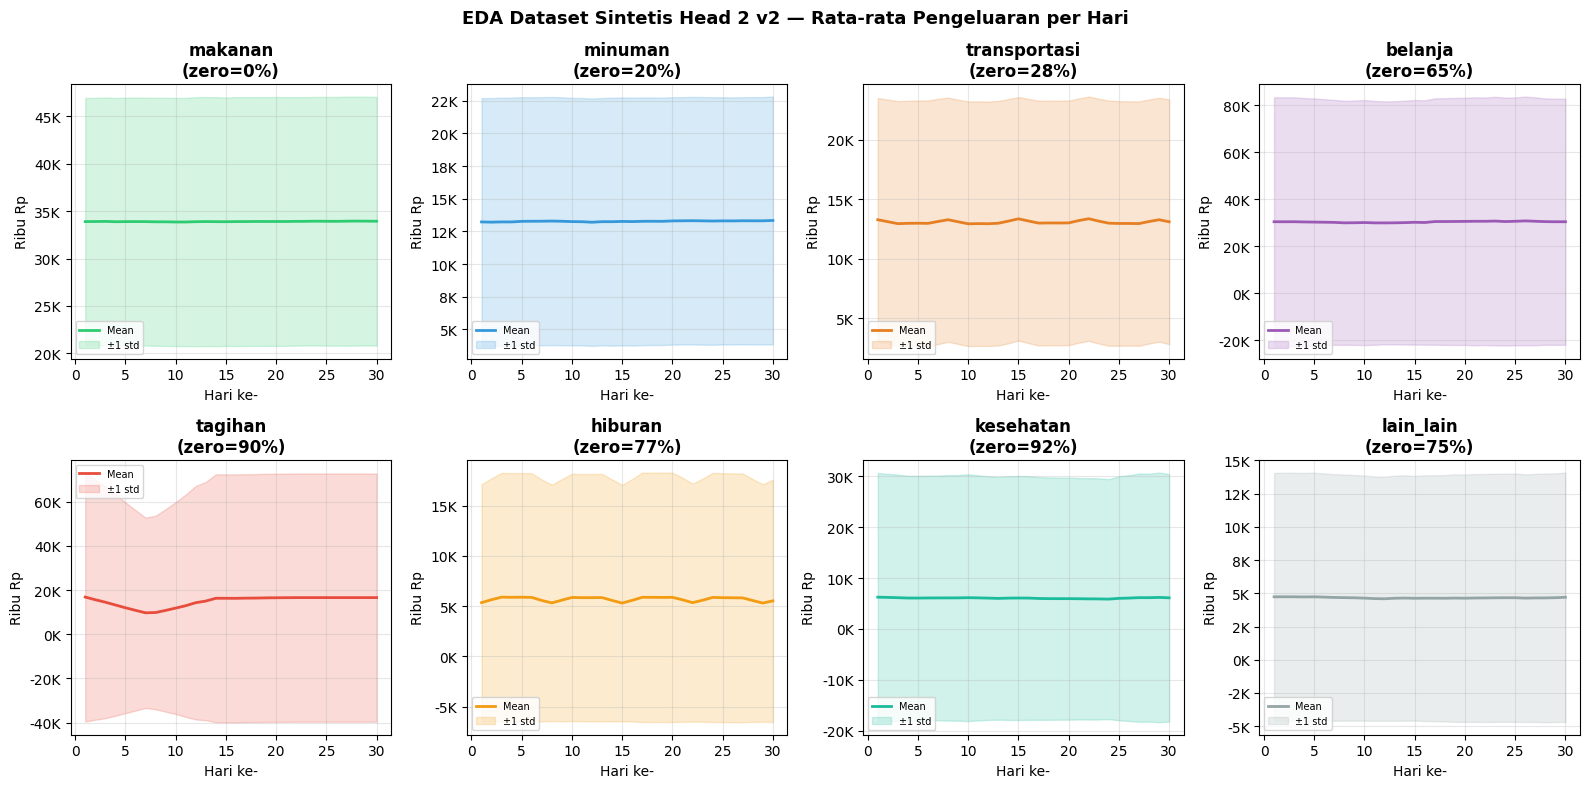


Statistik Dataset Head 2 v2:
Kategori            Mean      Std      Max    Zero%
----------------------------------------------------
makanan            33.9K    13.1K    77.4K     0.0%
minuman            13.3K     9.5K    42.6K    20.5%
transportasi       13.1K    10.3K    44.1K    27.6%
belanja            30.3K    52.3K   364.4K    64.7%
tagihan            14.9K    53.5K   472.0K    89.6%
hiburan             5.7K    12.2K    75.5K    76.9%
kesehatan           6.1K    24.0K   231.3K    92.0%
lain_lain           4.7K     9.3K    49.7K    75.1%

Total sampel : 8,100
Window size  : 30 hari
N kategori   : 8


In [ ]:
# ── EDA Visualisasi Dataset v2 ────────────────────────────────────────
# Pakai X_h2 langsung (numpy array) bukan df

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    ax = axes[i]

    # Ambil semua nilai dari X_h2 untuk kategori ini
    # X_h2 shape: (n_samples, 30, 8)
    # Rata-rata per posisi hari (0-29) di semua sampel
    mean_per_day = X_h2[:, :, i].mean(axis=0)  # (30,)
    std_per_day  = X_h2[:, :, i].std(axis=0)   # (30,)
    days         = range(1, 31)

    ax.plot(days, mean_per_day,
            color=CAT_COLORS[cat], linewidth=2, label='Mean')
    ax.fill_between(days,
                    mean_per_day - std_per_day,
                    mean_per_day + std_per_day,
                    alpha=0.2, color=CAT_COLORS[cat], label='±1 std')

    # Statistik
    zero_pct = (X_h2[:, :, i] == 0).mean() * 100
    ax.set_title(f"{cat}\n(zero={zero_pct:.0f}%)", fontweight='bold')
    ax.set_xlabel('Hari ke-')
    ax.set_ylabel('Ribu Rp')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:.0f}K')
    )

plt.suptitle(
    'EDA Dataset Sintetis Head 2 v2 — Rata-rata Pengeluaran per Hari',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('head2_eda.png', dpi=100, bbox_inches='tight')
plt.show()

# Ringkasan statistik
print("\nStatistik Dataset Head 2 v2:")
print(f"{'Kategori':<15} {'Mean':>8} {'Std':>8} {'Max':>8} {'Zero%':>8}")
print("-"*52)
for i, cat in enumerate(CATEGORIES):
    vals     = X_h2[:, :, i].flatten()
    mean_val = vals.mean()
    std_val  = vals.std()
    max_val  = vals.max()
    zero_pct = (vals == 0).mean() * 100
    print(f"{cat:<15} {mean_val:>7.1f}K {std_val:>7.1f}K "
          f"{max_val:>7.1f}K {zero_pct:>7.1f}%")

print(f"\nTotal sampel : {X_h2.shape[0]:,}")
print(f"Window size  : {X_h2.shape[1]} hari")
print(f"N kategori   : {X_h2.shape[2]}")

## Cell 5 — Preprocessing & Sliding Window

In [4]:
# Parameter
WINDOW_SIZE  = 30   # input: 30 hari riwayat
PRED_HORIZON = 7    # output: prediksi 7 hari ke depan

# ── X_h2 dan y_h2 sudah tersedia dari Cell 6 (dataset v2) ────────────
print(f"Dataset v2: X={X_h2.shape}, y={y_h2.shape}")

# ── Normalisasi per kategori dengan MinMaxScaler ──────────────────────
from sklearn.preprocessing import MinMaxScaler

scalers  = {}
X_scaled = np.zeros_like(X_h2)
y_scaled = np.zeros_like(y_h2)

for i, cat in enumerate(CATEGORIES):
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit HANYA pada X (input), bukan y
    X_flat = X_h2[:, :, i].reshape(-1, 1)
    scaler.fit(X_flat)

    X_scaled[:, :, i] = scaler.transform(
        X_h2[:, :, i].reshape(-1, 1)
    ).reshape(X_h2.shape[0], WINDOW_SIZE)

    y_scaled[:, :, i] = scaler.transform(
        y_h2[:, :, i].reshape(-1, 1)
    ).reshape(y_h2.shape[0], PRED_HORIZON)

    scalers[cat] = scaler

# ── Train / Val / Test split (70 / 15 / 15) ──────────────────────────
n       = len(X_scaled)
idx     = np.random.RandomState(42).permutation(n)
n_tr    = int(n * 0.70)
n_val   = int(n * 0.85)

idx_tr  = idx[:n_tr]
idx_val = idx[n_tr:n_val]
idx_te  = idx[n_val:]

X_train, y_train = X_scaled[idx_tr],  y_scaled[idx_tr]
X_val,   y_val   = X_scaled[idx_val], y_scaled[idx_val]
X_test,  y_test  = X_scaled[idx_te],  y_scaled[idx_te]

# Simpan y_test raw untuk evaluasi inverse transform
y_test_raw = y_h2[idx_te]

print(f"\nSplit dataset:")
print(f"  Train : {X_train.shape[0]:,} sampel")
print(f"  Val   : {X_val.shape[0]:,} sampel")
print(f"  Test  : {X_test.shape[0]:,} sampel")

# Cek distribusi dataset baru — pastikan tidak flat 0
print(f"\nCek zero% per kategori di y_test:")
for i, cat in enumerate(CATEGORIES):
    zero_pct = (y_test_raw[:, :, i] == 0).mean() * 100
    mean_val = y_test_raw[:, :, i].mean()
    print(f"  {cat:<15}: mean={mean_val:5.1f}rb | zero={zero_pct:.1f}%")

Dataset v2: X=(8100, 30, 8), y=(8100, 7, 8)

Split dataset:
  Train : 5,670 sampel
  Val   : 1,215 sampel
  Test  : 1,215 sampel

Cek zero% per kategori di y_test:
  makanan        : mean= 33.5rb | zero=0.0%
  minuman        : mean= 13.1rb | zero=20.4%
  transportasi   : mean= 13.1rb | zero=27.5%
  belanja        : mean= 29.8rb | zero=64.8%
  tagihan        : mean= 13.2rb | zero=90.2%
  hiburan        : mean=  5.5rb | zero=77.5%
  kesehatan      : mean=  6.1rb | zero=91.7%
  lain_lain      : mean=  4.5rb | zero=75.4%


## Cell 6 — Arsitektur Model MLP + GRU

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ── Custom Layers (Subclassing) ───────────────────────────────────────

class MLPEncoderLayer(layers.Layer):
    """
    MLP Encoder per timestep — ekstrak fitur dari setiap hari.
    Diaplikasikan secara independen ke setiap hari (TimeDistributed).
    """
    def __init__(self, units=64, dropout=0.2, **kwargs):
        super().__init__(**kwargs)
        self.dense1  = layers.Dense(units, activation='relu')
        self.dense2  = layers.Dense(units // 2, activation='relu')
        self.drop    = layers.Dropout(dropout)
        self.bn      = layers.BatchNormalization()
        self.units   = units
        self.dropout = dropout

    def call(self, x, training=False):
        # x: (batch, seq_len, n_cats)
        x = self.dense1(x)
        x = self.drop(x, training=training)
        x = self.dense2(x)
        return self.bn(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'dropout': self.dropout})
        return config


class StackedGRULayer(layers.Layer):
    """
    Stacked GRU 2 layer untuk menangkap pola temporal pengeluaran.
    Layer pertama return sequences untuk layer kedua.
    """
    def __init__(self, units_1=64, units_2=32,
                 dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.gru1    = layers.GRU(
            units_1, return_sequences=True,
            dropout=dropout, recurrent_dropout=0.1
        )
        self.gru2    = layers.GRU(
            units_2, return_sequences=False,
            dropout=dropout, recurrent_dropout=0.1
        )
        self.units_1 = units_1
        self.units_2 = units_2
        self.dropout = dropout

    def call(self, x, training=False):
        x = self.gru1(x, training=training)
        return self.gru2(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units_1': self.units_1,
            'units_2': self.units_2,
            'dropout': self.dropout,
        })
        return config


class MultiStepDecoderLayer(layers.Layer):
    """
    Decoder untuk menghasilkan prediksi multi-step (7 hari).
    Menggunakan Dense layer untuk project ke (horizon x n_cats).
    """
    def __init__(self, horizon, n_cats, units=128, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.n_cats  = n_cats
        self.dense1  = layers.Dense(units, activation='relu')
        self.dense2  = layers.Dense(units // 2, activation='relu')
        self.drop    = layers.Dropout(0.2)
        self.output_layer = layers.Dense(horizon * n_cats, activation='relu')
        self.reshape = layers.Reshape((horizon, n_cats))

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.drop(x, training=training)
        x = self.dense2(x)
        x = self.output_layer(x)
        return self.reshape(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'horizon': self.horizon,
            'n_cats' : self.n_cats,
        })
        return config


class CashFlowPredictor(Model):
    """
    Model prediksi arus kas mahasiswa.

    Input : (batch, window_size, n_cats) — riwayat 30 hari
    Output: (batch, pred_horizon, n_cats) — prediksi 7 hari
    """
    def __init__(self, window_size, pred_horizon, n_cats,
                 mlp_units=64, gru_units_1=64, gru_units_2=32,
                 decoder_units=128, **kwargs):
        super().__init__(**kwargs)
        self.window_size   = window_size
        self.pred_horizon  = pred_horizon
        self.n_cats        = n_cats

        # TimeDistributed MLP — proses setiap hari secara independen
        self.td_mlp  = layers.TimeDistributed(
            MLPEncoderLayer(mlp_units, dropout=0.2),
            name='mlp_encoder'
        )

        # Stacked GRU — tangkap pola temporal
        self.stacked_gru = StackedGRULayer(
            gru_units_1, gru_units_2, dropout=0.3,
            name='stacked_gru'
        )

        # Decoder — generate prediksi 7 hari
        self.decoder = MultiStepDecoderLayer(
            pred_horizon, n_cats, decoder_units,
            name='multi_step_decoder'
        )

    def call(self, x, training=False):
        # x: (batch, 30, 8)
        x = self.td_mlp(x, training=training)   # (batch, 30, 32)
        x = self.stacked_gru(x, training=training)  # (batch, 32)
        return self.decoder(x, training=training)    # (batch, 7, 8)

    def get_config(self):
        return {
            'window_size'  : self.window_size,
            'pred_horizon' : self.pred_horizon,
            'n_cats'       : self.n_cats,
        }


# ── Build model ───────────────────────────────────────────────────────
model_head2 = CashFlowPredictor(
    window_size   = WINDOW_SIZE,
    pred_horizon  = PRED_HORIZON,
    n_cats        = N_CATS,
    mlp_units     = 64,
    gru_units_1   = 64,
    gru_units_2   = 32,
    decoder_units = 128,
    name          = "CashFlowPredictor"
)

# Build dengan dummy input
_ = model_head2(tf.zeros((1, WINDOW_SIZE, N_CATS)))

n_params = sum(tf.size(v).numpy() for v in model_head2.trainable_variables)
print("Model CashFlowPredictor siap!")
print(f"  Trainable params : {n_params:,}")
print(f"  Input shape      : (batch, {WINDOW_SIZE}, {N_CATS})")
print(f"  Output shape     : (batch, {PRED_HORIZON}, {N_CATS})")
print()
print("Arsitektur:")
print("  TimeDistributed(MLPEncoder) → StackedGRU(64→32) → MultiStepDecoder")

Model CashFlowPredictor siap!
  Trainable params : 47,064
  Input shape      : (batch, 30, 8)
  Output shape     : (batch, 7, 8)

Arsitektur:
  TimeDistributed(MLPEncoder) → StackedGRU(64→32) → MultiStepDecoder


In [6]:
# ── Verifikasi output model fresh (sebelum training) ──────────────────
# Output random sebelum training harusnya > 0 untuk semua kategori
test_input = tf.random.normal((4, WINDOW_SIZE, N_CATS))
test_out   = model_head2(test_input, training=False).numpy()
print(f"\nOutput model fresh (mean per kategori):")
for i, cat in enumerate(CATEGORIES):
    print(f"  {cat:<15}: {test_out[:,:,i].mean():.4f}")
print("Kalau semua > 0 berarti arsitektur sudah benar")


Output model fresh (mean per kategori):
  makanan        : 0.0170
  minuman        : 0.0088
  transportasi   : 0.0061
  belanja        : 0.0087
  tagihan        : 0.0142
  hiburan        : 0.0091
  kesehatan      : 0.0149
  lain_lain      : 0.0186
Kalau semua > 0 berarti arsitektur sudah benar


## Cell 7 — Custom Loss & Training Loop

Model di-reset dari awal.
Sampel dengan spike: 5,670 dari 5,670
Total setelah augmentasi: 22,680
Loss: SporadicAwareLoss | spike_penalty=5.0

TRAINING Head 2 — SporadicAwareLoss + Oversampling
  Epochs=60 | Batch=64 | LR=0.0005 | Patience=12
------------------------------------------------------------
Epoch  1/60 | loss=0.8055 val=0.5338 | mae=0.1595 val_mae=0.1284 | 53.2s
  -> Best val_loss=0.5338
Epoch  2/60 | loss=0.4441 val=0.4102 | mae=0.1080 val_mae=0.0985 | 31.0s
  -> Best val_loss=0.4102
Epoch  3/60 | loss=0.3874 val=0.4002 | mae=0.0985 val_mae=0.1004 | 30.8s
  -> Best val_loss=0.4002
Epoch  4/60 | loss=0.3720 val=0.3806 | mae=0.0982 val_mae=0.1004 | 31.3s
  -> Best val_loss=0.3806
Epoch  5/60 | loss=0.3649 val=0.3789 | mae=0.0980 val_mae=0.1002 | 31.1s
  -> Best val_loss=0.3789
Epoch  6/60 | loss=0.3617 val=0.3788 | mae=0.0977 val_mae=0.1012 | 31.1s
  -> Best val_loss=0.3788
Epoch  7/60 | loss=0.3603 val=0.3552 | mae=0.0975 val_mae=0.0986 | 31.0s
  -> Best val_loss=0.3552
Epoc

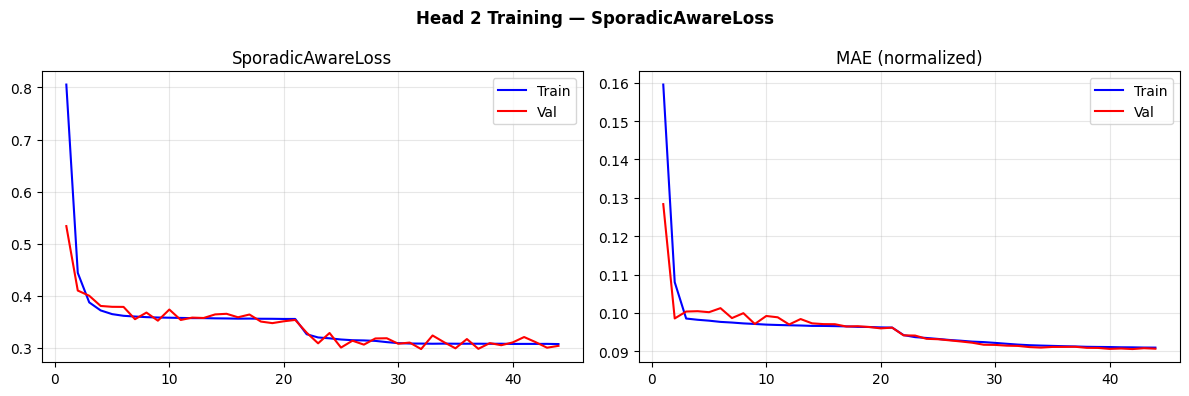

In [7]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_absolute_error

# ── 1. Custom Loss ────────────────────────────────────────────────────
class SporadicAwareLoss(tf.keras.losses.Loss):
    def __init__(self, category_weights=None, spike_penalty=5.0, **kwargs):
        super().__init__(**kwargs)
        if category_weights is None:
            category_weights = [1.0] * 8
        self.weights       = tf.constant(category_weights, dtype=tf.float32)
        self.spike_penalty = spike_penalty

    def call(self, y_true, y_pred):
        mae        = tf.abs(y_true - y_pred)
        weighted   = mae * self.weights
        threshold  = 0.05
        is_spike   = tf.cast(y_true > threshold, tf.float32)
        is_miss    = tf.cast(y_pred < threshold, tf.float32)
        miss_spike = is_spike * is_miss
        penalty    = miss_spike * tf.abs(y_true - y_pred) * self.spike_penalty
        return tf.reduce_mean(weighted + penalty)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'category_weights': self.weights.numpy().tolist(),
            'spike_penalty'   : self.spike_penalty,
        })
        return cfg


# ── 2. LR Schedule ────────────────────────────────────────────────────
class WarmupExponentialDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, decay_steps, decay_rate):
        super().__init__()
        self.base_lr      = base_lr
        self.warmup_steps = float(warmup_steps)
        self.decay_steps  = float(decay_steps)
        self.decay_rate   = decay_rate

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        warmup = step / self.warmup_steps * self.base_lr
        decay  = self.base_lr * tf.pow(
            self.decay_rate,
            (step - self.warmup_steps) / self.decay_steps
        )
        return tf.where(step < self.warmup_steps, warmup, decay)

    def get_config(self):
        return {
            'base_lr'     : self.base_lr,
            'warmup_steps': self.warmup_steps,
            'decay_steps' : self.decay_steps,
            'decay_rate'  : self.decay_rate,
        }


# ── 3. Hyperparameter ─────────────────────────────────────────────────
EPOCHS     = 60
BATCH_SIZE = 64
BASE_LR    = 5e-4
PATIENCE   = 12
GRAD_CLIP  = 1.0

category_weights_v2 = [
    2.0,  # makanan
    1.5,  # minuman
    1.5,  # transportasi
    3.0,  # belanja
    4.0,  # tagihan
    3.0,  # hiburan
    3.0,  # kesehatan
    1.5,  # lain_lain
]

# ── 4. Reset model ────────────────────────────────────────────────────
model_head2 = CashFlowPredictor(
    n_cats       = N_CATS,
    window_size  = WINDOW_SIZE,
    pred_horizon = PRED_HORIZON,
)
_ = model_head2(tf.zeros((1, WINDOW_SIZE, N_CATS)))
print("Model di-reset dari awal.")

# ── 5. Oversampling (HARUS SEBELUM total_steps) ───────────────────────
spike_cats = [
    CATEGORIES.index('tagihan'),
    CATEGORIES.index('hiburan'),
    CATEGORIES.index('kesehatan'),
    CATEGORIES.index('belanja'),
]

has_spike = np.zeros(len(X_train), dtype=bool)
for cat_i in spike_cats:
    has_spike |= (X_train[:, :, cat_i].max(axis=1) > 0.05)

spike_idx   = np.where(has_spike)[0]
print(f"Sampel dengan spike: {len(spike_idx):,} dari {len(X_train):,}")

X_train_aug = np.concatenate([
    X_train,
    X_train[spike_idx],
    X_train[spike_idx],
    X_train[spike_idx],
], axis=0)
y_train_aug = np.concatenate([
    y_train,
    y_train[spike_idx],
    y_train[spike_idx],
    y_train[spike_idx],
], axis=0)

aug_idx     = np.random.RandomState(42).permutation(len(X_train_aug))
X_train_aug = X_train_aug[aug_idx]
y_train_aug = y_train_aug[aug_idx]
print(f"Total setelah augmentasi: {len(X_train_aug):,}")

# ── 6. Optimizer (SETELAH X_train_aug tersedia) ───────────────────────
total_steps  = (len(X_train_aug) // BATCH_SIZE) * EPOCHS
warmup_steps = total_steps // 10

lr_schedule = WarmupExponentialDecay(
    BASE_LR, warmup_steps,
    decay_steps = total_steps // 2,
    decay_rate  = 0.5
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
loss_fn   = SporadicAwareLoss(
    category_weights = category_weights_v2,
    spike_penalty    = 5.0,
)
print(f"Loss: SporadicAwareLoss | spike_penalty=5.0")

# ── 7. Dataset ────────────────────────────────────────────────────────
train_ds = (tf.data.Dataset
    .from_tensor_slices((X_train_aug, y_train_aug))
    .shuffle(len(X_train_aug), seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

# ── 8. Training Loop ──────────────────────────────────────────────────
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred     = model_head2(x_batch, training=True)
        loss       = loss_fn(y_batch, y_pred)
        l2         = tf.add_n([
            tf.nn.l2_loss(v)
            for v in model_head2.trainable_variables
            if 'kernel' in v.name
        ]) * 1e-5
        total_loss = loss + l2
    grads = tape.gradient(total_loss, model_head2.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP)
    optimizer.apply_gradients(zip(grads, model_head2.trainable_variables))
    return total_loss, y_pred


@tf.function
def val_step(x_batch, y_batch):
    y_pred = model_head2(x_batch, training=False)
    loss   = loss_fn(y_batch, y_pred)
    return loss, y_pred


print("\n" + "="*60)
print("TRAINING Head 2 — SporadicAwareLoss + Oversampling")
print("="*60)
print(f"  Epochs={EPOCHS} | Batch={BATCH_SIZE} | LR={BASE_LR} | Patience={PATIENCE}")
print("-"*60)

history_h2     = {'train_loss':[], 'val_loss':[], 'train_mae':[], 'val_mae':[]}
best_val_loss  = float('inf')
best_weights   = None
patience_count = 0

for epoch in range(EPOCHS):
    t0 = time.time()

    tr_losses, tr_preds, tr_true = [], [], []
    for xb, yb in train_ds:
        loss, pred = train_step(xb, yb)
        tr_losses.append(loss.numpy())
        tr_preds.append(pred.numpy())
        tr_true.append(yb.numpy())

    tr_loss = np.mean(tr_losses)
    tr_mae  = np.mean(np.abs(
        np.concatenate(tr_preds) - np.concatenate(tr_true)
    ))

    vl_losses, vl_preds, vl_true = [], [], []
    for xb, yb in val_ds:
        loss, pred = val_step(xb, yb)
        vl_losses.append(loss.numpy())
        vl_preds.append(pred.numpy())
        vl_true.append(yb.numpy())

    vl_loss = np.mean(vl_losses)
    vl_mae  = np.mean(np.abs(
        np.concatenate(vl_preds) - np.concatenate(vl_true)
    ))

    history_h2['train_loss'].append(tr_loss)
    history_h2['val_loss'  ].append(vl_loss)
    history_h2['train_mae' ].append(tr_mae)
    history_h2['val_mae'   ].append(vl_mae)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"loss={tr_loss:.4f} val={vl_loss:.4f} | "
          f"mae={tr_mae:.4f} val_mae={vl_mae:.4f} | "
          f"{time.time()-t0:.1f}s")

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_weights   = [v.numpy() for v in model_head2.trainable_variables]
        patience_count = 0
        print(f"  -> Best val_loss={best_val_loss:.4f}")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping epoch {epoch+1}")
            break

if best_weights:
    for v, w in zip(model_head2.trainable_variables, best_weights):
        v.assign(w)

print(f"\nTraining selesai! Best val_loss={best_val_loss:.4f}")

# ── 9. Verifikasi cepat ───────────────────────────────────────────────
print("\nVerifikasi output model (sampel dengan tagihan > 0):")
cat_idx = CATEGORIES.index('tagihan')
sampel  = np.where(y_test[:, :, cat_idx].sum(axis=1) > 0.01)[0]

if len(sampel) > 0:
    xb   = X_test[sampel[0]:sampel[0]+1]
    pred = model_head2(xb, training=False).numpy()[0]
    true = y_test[sampel[0]]
    print(f"{'Kategori':<15} {'True (scaled)':>15} {'Pred (scaled)':>15}")
    print("-"*47)
    for i, cat in enumerate(CATEGORIES):
        flag = " <- CEK" if cat in ['tagihan','hiburan','kesehatan','belanja'] else ""
        print(f"{cat:<15} {true[:,i].mean():>15.4f} {pred[:,i].mean():>15.4f}{flag}")

# ── 10. Plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history_h2['train_loss'])+1)
ax1.plot(ep, history_h2['train_loss'], 'b-', label='Train')
ax1.plot(ep, history_h2['val_loss'],   'r-', label='Val')
ax1.set_title('SporadicAwareLoss'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(ep, history_h2['train_mae'], 'b-', label='Train')
ax2.plot(ep, history_h2['val_mae'],   'r-', label='Val')
ax2.set_title('MAE (normalized)'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle('Head 2 Training — SporadicAwareLoss', fontweight='bold')
plt.tight_layout()
plt.savefig('head2_training.png', dpi=100, bbox_inches='tight')
plt.show()

## Cell 8 — Evaluasi

EVALUASI Head 2 — Test Set (satuan: ribuan Rupiah)
Kategori          MAE (rb)  RMSE (rb)   MAPE (%)   Zero GT%
----------------------------------------------------------
makanan               5.7K       7.0K      17.0%       0.0%
minuman               6.5K       8.5K      27.0%      20.4%
transportasi          6.5K       8.4K      28.6%      27.5%
belanja              35.3K      53.0K      68.4%      64.8%
tagihan              13.2K      51.6K     100.0%      90.2%
hiburan               5.4K      12.1K      87.1%      77.5%
kesehatan             6.1K      24.7K     100.0%      91.7%
lain_lain             5.8K       9.4K      82.6%      75.4%
----------------------------------------------------------
OVERALL              10.5K

Sampel terpilih untuk visualisasi: #8
Kategori dengan pengeluaran > 0: 8/8


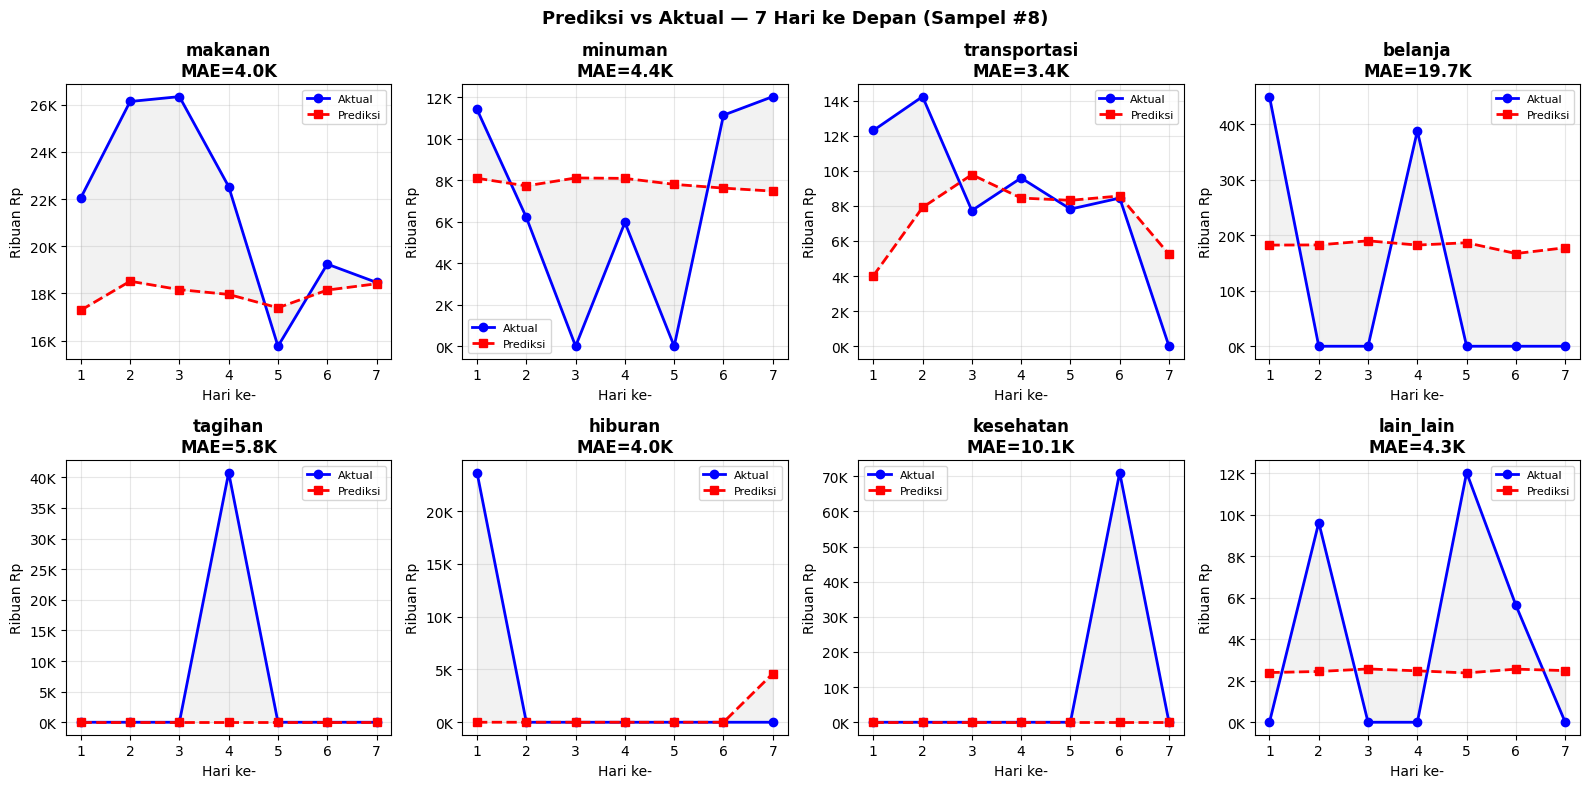

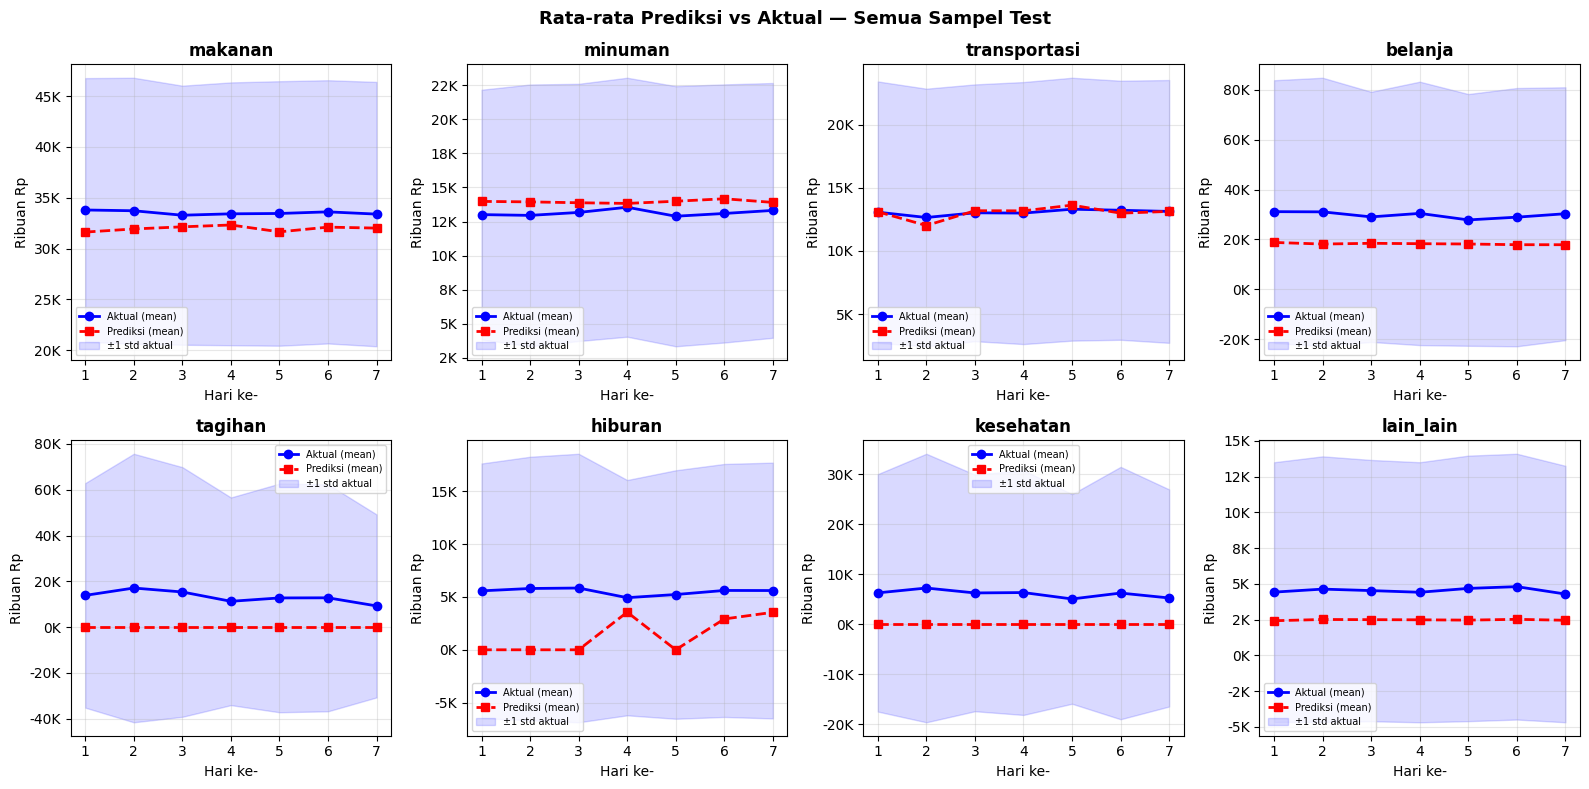

In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Prediksi pada test set ────────────────────────────────────────────
y_pred_scaled = model_head2.predict(X_test, batch_size=64, verbose=0)

# ── Inverse transform ke satuan asli (ribuan Rupiah) ──────────────────
# CATATAN: y_test_raw sudah dalam ribuan Rp, TIDAK dikali 1000 lagi
y_pred_raw = np.zeros_like(y_pred_scaled)

for i, cat in enumerate(CATEGORIES):
    scaler = scalers[cat]
    y_pred_raw[:, :, i] = scaler.inverse_transform(
        y_pred_scaled[:, :, i].reshape(-1, 1)
    ).reshape(y_pred_scaled.shape[0], PRED_HORIZON)

# Clip negatif
y_pred_raw = np.clip(y_pred_raw, 0, None)
y_true_raw = y_h2[idx_te]  # ground truth dalam ribuan Rp

# ── Metrik per kategori ───────────────────────────────────────────────
print("=" * 65)
print("EVALUASI Head 2 — Test Set (satuan: ribuan Rupiah)")
print("=" * 65)
print(f"{'Kategori':<15} {'MAE (rb)':>10} {'RMSE (rb)':>10} {'MAPE (%)':>10} {'Zero GT%':>10}")
print("-" * 58)

for i, cat in enumerate(CATEGORIES):
    true = y_true_raw[:, :, i].flatten()  # ribuan Rp
    pred = y_pred_raw[:, :, i].flatten()  # ribuan Rp

    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))

    # MAPE hanya untuk nilai > 0 (skip hari dengan pengeluaran 0)
    mask = true > 0
    mape = (np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100
            if mask.sum() > 0 else float('nan'))

    # Persentase ground truth yang 0 (hari tidak ada pengeluaran)
    zero_gt = (true == 0).mean() * 100

    print(f"{cat:<15} {mae:>9.1f}K {rmse:>9.1f}K "
          f"{mape:>9.1f}% {zero_gt:>9.1f}%")

print("-" * 58)
total_mae = mean_absolute_error(y_true_raw.flatten(), y_pred_raw.flatten())
print(f"{'OVERALL':<15} {total_mae:>9.1f}K")

# ── Pilih sampel yang representatif untuk visualisasi ─────────────────
# Cari sampel yang punya variasi di semua kategori (bukan semua 0)
best_sample_idx = 0
best_nonzero    = 0

for idx in range(min(200, len(y_true_raw))):
    # Hitung berapa kategori yang punya nilai > 0 di 7 hari
    nonzero_cats = sum(
        y_true_raw[idx, :, i].sum() > 0
        for i in range(N_CATS)
    )
    if nonzero_cats > best_nonzero:
        best_nonzero    = nonzero_cats
        best_sample_idx = idx

print(f"\nSampel terpilih untuk visualisasi: #{best_sample_idx}")
print(f"Kategori dengan pengeluaran > 0: {best_nonzero}/{N_CATS}")

# ── Visualisasi prediksi vs aktual ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    ax   = axes[i]
    true = y_true_raw[best_sample_idx, :, i]  # ribuan Rp
    pred = y_pred_raw[best_sample_idx, :, i]  # ribuan Rp
    days = range(1, PRED_HORIZON + 1)

    ax.plot(days, true, 'b-o', label='Aktual',   linewidth=2, markersize=6)
    ax.plot(days, pred, 'r--s', label='Prediksi', linewidth=2, markersize=6)

    # Warna area gap
    ax.fill_between(days, true, pred, alpha=0.1, color='gray')

    # MAE untuk sampel ini
    mae_sample = mean_absolute_error(true, pred)
    ax.set_title(f"{cat}\nMAE={mae_sample:.1f}K", fontweight='bold')
    ax.set_xlabel('Hari ke-')
    ax.set_ylabel('Ribuan Rp')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:.0f}K')
    )

    # Kalau prediksi dan aktual sama-sama 0 → tambahkan keterangan
    if true.sum() == 0 and pred.sum() == 0:
        ax.text(0.5, 0.5, 'Tidak ada\npengeluaran',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='gray', alpha=0.7)

plt.suptitle(
    f'Prediksi vs Aktual — 7 Hari ke Depan (Sampel #{best_sample_idx})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('head2_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Visualisasi agregat: rata-rata prediksi vs aktual ─────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    ax        = axes[i]
    true_mean = y_true_raw[:, :, i].mean(axis=0)  # rata-rata semua sampel
    pred_mean = y_pred_raw[:, :, i].mean(axis=0)
    true_std  = y_true_raw[:, :, i].std(axis=0)
    days      = range(1, PRED_HORIZON + 1)

    ax.plot(days, true_mean, 'b-o', label='Aktual (mean)',   linewidth=2)
    ax.plot(days, pred_mean, 'r--s', label='Prediksi (mean)', linewidth=2)
    ax.fill_between(days,
                    true_mean - true_std,
                    true_mean + true_std,
                    alpha=0.15, color='blue', label='±1 std aktual')

    ax.set_title(cat, fontweight='bold')
    ax.set_xlabel('Hari ke-')
    ax.set_ylabel('Ribuan Rp')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:.0f}K')
    )

plt.suptitle(
    'Rata-rata Prediksi vs Aktual — Semua Sampel Test',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('head2_evaluation_agregat.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
def predict_cashflow_dict(actual_dict, day_of_month=None):
    """
    Prediksi 7 hari ke depan.

    Args:
        actual_dict  : {kategori: total_rupiah_bulan_ini}
                       contoh: {'makanan': 525000, 'tagihan': 100000}
        day_of_month : hari ke berapa (default: hari ini)

    Returns:
        dict {kategori: prediksi_total_7hari_rupiah}
    """
    from datetime import datetime
    if day_of_month is None:
        day_of_month = datetime.now().day
    days_elapsed = max(1, day_of_month)

    # ── Step 1: Konversi ke ribuan Rp (satuan dataset) ────────────────
    actual_rb = {cat: val / 1000 for cat, val in actual_dict.items()}

    # ── Step 2: Buat input sequence ───────────────────────────────────
    x_input = np.zeros((1, WINDOW_SIZE, N_CATS), dtype=np.float32)

    for i, cat in enumerate(CATEGORIES):
        daily_avg_rb = actual_rb.get(cat, 0) / days_elapsed  # ribuan Rp/hari

        # Simulasi 30 hari dengan variasi natural
        rng = np.random.RandomState(42 + i)
        seq = np.array([
            max(0, daily_avg_rb * (1 + rng.normal(0, 0.12)))
            for _ in range(WINDOW_SIZE)
        ], dtype=np.float32)

        # Normalisasi dengan scaler yang sama saat training
        x_input[0, :, i] = scalers[cat].transform(
            seq.reshape(-1, 1)
        ).flatten()

    # ── Step 3: Inference model ───────────────────────────────────────
    pred_scaled = model_head2(x_input, training=False).numpy()[0]

    # ── Step 4: Inverse transform ke ribuan Rp ───────────────────────
    pred_rb = np.zeros((PRED_HORIZON, N_CATS), dtype=np.float32)
    for i, cat in enumerate(CATEGORIES):
        raw = scalers[cat].inverse_transform(
            pred_scaled[:, i].reshape(-1, 1)
        ).flatten()
        pred_rb[:, i] = np.clip(raw, 0, None)

    # ── Step 5: Fallback untuk kategori yang model under-predict ──────
    pred_7d = {}
    FALLBACK_THRESHOLD = 0.15  # kalau pred < 15% dari expected → fallback

    print(f"\n{'Kategori':<15} {'Daily avg':>10} {'Pred/hari':>10} {'Sumber':>10}")
    print("-"*50)

    for i, cat in enumerate(CATEGORIES):
        daily_avg_rb   = actual_rb.get(cat, 0) / days_elapsed
        pred_total_rb  = float(pred_rb[:, i].sum())   # total 7 hari dalam ribuan
        pred_daily_rb  = pred_total_rb / PRED_HORIZON  # per hari

        # Fallback kalau ada aktual tapi prediksi terlalu kecil
        expected_7d_rb = daily_avg_rb * PRED_HORIZON
        if (expected_7d_rb > 0 and
                pred_total_rb < expected_7d_rb * FALLBACK_THRESHOLD):
            # Fallback: pakai daily average dengan slight decay
            pred_7d[cat]  = round(daily_avg_rb * PRED_HORIZON * 0.85 * 1000)
            sumber = "fallback"
        else:
            pred_7d[cat]  = round(pred_total_rb * 1000)  # ke Rupiah
            sumber = "model"

        print(f"{cat:<15} {daily_avg_rb:>9.1f}K {pred_daily_rb:>9.1f}K {sumber:>10}")

    print("-"*50)
    total = sum(pred_7d[c] for c in CATEGORIES)
    print(f"Total prediksi 7 hari: Rp {total:,}".replace(',','.'))

    return pred_7d


# ── Test ──────────────────────────────────────────────────────────────
actual_test = {
    'makanan'      : 525000,
    'minuman'      : 200000,
    'transportasi' : 195000,
    'belanja'      : 150000,
    'tagihan'      : 100000,
    'hiburan'      : 50000,
    'kesehatan'    : 30000,
    'lain_lain'    : 45000,
}

pred = predict_cashflow_dict(actual_test, day_of_month=15)

print(f"\nHasil prediksi per kategori:")
for cat in CATEGORIES:
    print(f"  {cat:<15}: Rp {pred[cat]:>10,}".replace(',','.'))


Kategori         Daily avg  Pred/hari     Sumber
--------------------------------------------------
makanan              35.0K      24.1K      model
minuman              13.3K      10.4K      model
transportasi         13.0K      10.1K      model
belanja              10.0K      18.3K      model
tagihan               6.7K       0.0K   fallback
hiburan               3.3K       0.9K      model
kesehatan             2.0K       0.0K   fallback
lain_lain             3.0K       2.5K      model
--------------------------------------------------
Total prediksi 7 hari: Rp 515.701

Hasil prediksi per kategori:
  makanan        : Rp    169.009
  minuman        : Rp     72.764
  transportasi   : Rp     70.868
  belanja        : Rp    127.871
  tagihan        : Rp     39.667
  hiburan        : Rp      6.452
  kesehatan      : Rp     11.900
  lain_lain      : Rp     17.170


In [11]:
# Jalankan cell diagnosis ini dulu sebelum apapun

print("="*60)
print("DIAGNOSIS HEAD 2")
print("="*60)

# 1. Cek apakah X_train benar-benar dari dataset v2
print("\n[1] Cek distribusi X_train per kategori:")
for i, cat in enumerate(CATEGORIES):
    zero_pct = (X_train[:, :, i] == 0).mean() * 100
    mean_val = X_train[:, :, i].mean()
    print(f"  {cat:<15}: mean={mean_val:.3f} (scaled) | zero={zero_pct:.1f}%")

# 2. Cek apakah y_train punya variasi untuk kategori sporadis
print("\n[2] Cek distribusi y_train per kategori:")
for i, cat in enumerate(CATEGORIES):
    zero_pct = (y_train[:, :, i] == 0).mean() * 100
    mean_val = y_train[:, :, i].mean()
    max_val  = y_train[:, :, i].max()
    print(f"  {cat:<15}: mean={mean_val:.3f} | max={max_val:.3f} | zero={zero_pct:.1f}%")

# 3. Cek output model untuk input yang punya tagihan/hiburan
print("\n[3] Cek output model untuk sampel dengan tagihan > 0:")
# Cari sampel test yang punya tagihan > 0
cat_idx = CATEGORIES.index('tagihan')
sampel_dengan_tagihan = np.where(
    y_test[:, :, cat_idx].sum(axis=1) > 0.01
)[0]

print(f"  Sampel test dengan tagihan > 0: {len(sampel_dengan_tagihan)}")

if len(sampel_dengan_tagihan) > 0:
    idx_sample = sampel_dengan_tagihan[0]
    x_sample   = X_test[idx_sample:idx_sample+1]
    y_true_s   = y_test[idx_sample]
    y_pred_s   = model_head2(x_sample, training=False).numpy()[0]

    print(f"\n  Sampel #{idx_sample}:")
    print(f"  {'Kategori':<15} {'y_true (scaled)':>18} {'y_pred (scaled)':>18}")
    print(f"  {'-'*54}")
    for i, cat in enumerate(CATEGORIES):
        true_mean = y_true_s[:, i].mean()
        pred_mean = y_pred_s[:, i].mean()
        print(f"  {cat:<15} {true_mean:>18.4f} {pred_mean:>18.4f}")

# 4. Cek scaler tagihan
print("\n[4] Cek scaler per kategori:")
for cat in ['tagihan', 'hiburan', 'kesehatan']:
    sc = scalers[cat]
    print(f"  {cat}: data_min={sc.data_min_[0]:.2f} | "
          f"data_max={sc.data_max_[0]:.2f} | "
          f"scale={sc.scale_[0]:.6f}")

# 5. Cek apakah idx_te tersedia
print("\n[5] Cek idx_te dan y_h2:")
try:
    print(f"  idx_te tersedia: {len(idx_te)} sampel")
    print(f"  y_h2 shape: {y_h2.shape}")
    for i, cat in enumerate(CATEGORIES):
        zero_pct = (y_h2[idx_te, :, i] == 0).mean() * 100
        print(f"  {cat:<15}: zero GT = {zero_pct:.1f}%")
except NameError as e:
    print(f"  ERROR: {e}")
    print("  -> idx_te tidak tersedia, Cell 10 mungkin belum dijalankan ulang")

DIAGNOSIS HEAD 2

[1] Cek distribusi X_train per kategori:
  makanan        : mean=0.358 (scaled) | zero=0.0%
  minuman        : mean=0.313 (scaled) | zero=20.4%
  transportasi   : mean=0.298 (scaled) | zero=27.7%
  belanja        : mean=0.083 (scaled) | zero=64.8%
  tagihan        : mean=0.032 (scaled) | zero=89.6%
  hiburan        : mean=0.075 (scaled) | zero=77.0%
  kesehatan      : mean=0.026 (scaled) | zero=92.0%
  lain_lain      : mean=0.094 (scaled) | zero=75.0%

[2] Cek distribusi y_train per kategori:
  makanan        : mean=0.359 | max=1.000 | zero=0.0%
  minuman        : mean=0.314 | max=1.000 | zero=20.1%
  transportasi   : mean=0.298 | max=1.000 | zero=27.5%
  belanja        : mean=0.084 | max=1.000 | zero=64.4%
  tagihan        : mean=0.027 | max=1.000 | zero=90.7%
  hiburan        : mean=0.075 | max=0.983 | zero=77.3%
  kesehatan      : mean=0.027 | max=0.978 | zero=91.9%
  lain_lain      : mean=0.096 | max=1.000 | zero=74.6%

[3] Cek output model untuk sampel dengan tag

## Cell 9 — Simpan Model ke Google Drive

In [13]:
import pickle

try:
    from google.colab import drive
    drive.mount('/content/drive')

    save_dir = '/content/drive/MyDrive/LaporKeuangan/Head2'
    os.makedirs(save_dir, exist_ok=True)

    # Simpan weights model
    model_head2.save_weights(f'{save_dir}/head2.weights.h5')

    # Simpan scalers
    with open(f'{save_dir}/head2_scalers.pkl', 'wb') as f:
        pickle.dump(scalers, f)

    # Simpan config
    config = {
        'window_size'  : WINDOW_SIZE,
        'pred_horizon' : PRED_HORIZON,
        'n_cats'       : N_CATS,
        'categories'   : CATEGORIES,
        'best_val_loss': float(best_val_loss),
    }
    with open(f'{save_dir}/head2_config.json', 'w') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)

    print(f"Model Head 2 tersimpan di: {save_dir}")
    print(f"  head2_weights.h5")
    print(f"  head2_scalers.pkl")
    print(f"  head2_config.json")

except Exception as e:
    print(f"Gagal simpan ke Drive: {e}")
    print("Model tersimpan di memory session ini.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model Head 2 tersimpan di: /content/drive/MyDrive/LaporKeuangan/Head2
  head2_weights.h5
  head2_scalers.pkl
  head2_config.json


In [14]:
import pandas as pd
import numpy as np

# Flatten X_h2 (30 days) and y_h2 (7 days) into a single dataframe
# Columns: sample_id, day_index, cat_1, cat_2, ...

n_samples, n_days_x, n_cats = X_h2.shape
n_days_y = y_h2.shape[1]

rows = []
for i in range(n_samples):
    # Combine X and y for this sample (37 days total)
    combined_seq = np.vstack([X_h2[i], y_h2[i]])
    for day in range(n_days_x + n_days_y):
        row = {
            'sample_id': i,
            'day_relative': day + 1,
            'is_prediction_target': day >= n_days_x
        }
        for cat_idx, cat_name in enumerate(CATEGORIES):
            row[cat_name] = combined_seq[day, cat_idx]
        rows.append(row)

df_synthetic = pd.DataFrame(rows)

# Save to CSV
csv_path = 'head2_synthetic_dataset.csv'
df_synthetic.to_csv(csv_path, index=False)

print(f"Dataset sintetis berhasil disimpan ke: {csv_path}")
print(f"Total baris: {len(df_synthetic):,}")
display(df_synthetic.head(10))

Dataset sintetis berhasil disimpan ke: head2_synthetic_dataset.csv
Total baris: 299,700


,sample_id,day_relative,is_prediction_target,makanan,minuman,transportasi,belanja,tagihan,hiburan,kesehatan,lain_lain
0,0,1,False,45.840683,12.756376,13.967379,0.000000,0.000000,0.000000,157.654556,0.000000
1,0,2,False,32.086979,13.288898,22.033619,0.000000,219.258270,0.000000,0.000000,0.000000
2,0,3,False,38.537804,13.605257,23.203060,69.137474,310.281158,0.000000,0.000000,0.000000
3,0,4,False,29.052088,18.281399,21.522350,107.306831,0.000000,0.000000,0.000000,0.000000
4,0,5,False,31.359543,0.000000,29.202265,0.000000,0.000000,0.000000,0.000000,9.814887
5,0,6,False,35.077518,14.998992,0.000000,0.000000,200.580994,45.015835,160.130463,0.000000
6,0,7,False,31.726408,25.579336,0.000000,0.000000,0.000000,29.676424,0.000000,0.000000
7,0,8,False,42.963833,10.958472,18.584084,0.000000,0.000000,0.000000,0.000000,27.134481
8,0,9,False,46.602699,24.714138,21.998642,0.000000,28.598928,19.642366,0.000000,0.000000
9,0,10,False,50.487564,17.702526,16.918106,44.940079,0.000000,0.000000,0.000000,0.000000


## Cell 10 — Inference: Prediksi 7 Hari ke Depan

Demo prediksi untuk user 0 (30 hari terakhir)...


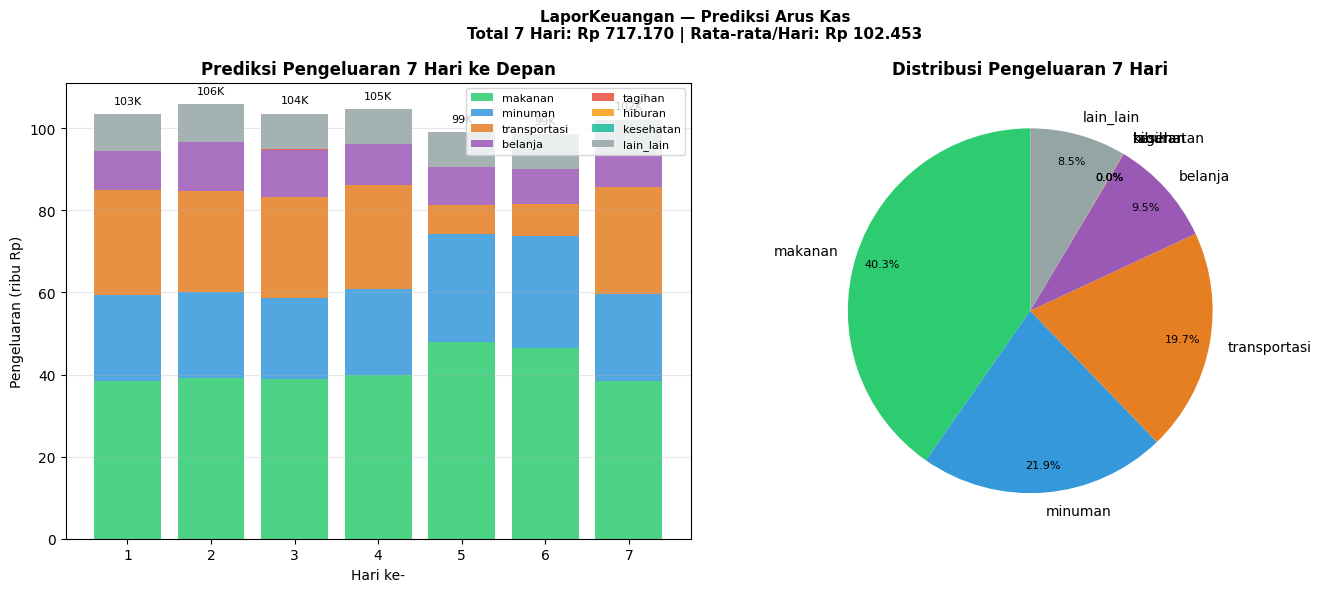


── Prediksi Pengeluaran 7 Hari ke Depan ──────────────
Hari   Tanggal           Total    Makanan  Minuman  Transport
------------------------------------------------------------
  +1    2025-04-01   Rp 103.413 Rp 38.428 Rp 20.865 Rp  25.639
  +2    2025-04-02   Rp 105.780 Rp 39.130 Rp 21.024 Rp  24.640
  +3    2025-04-03   Rp 103.544 Rp 38.919 Rp 19.600 Rp  24.682
  +4    2025-04-04   Rp 104.700 Rp 39.943 Rp 20.855 Rp  25.441
  +5    2025-04-05   Rp  99.033 Rp 47.852 Rp 26.403 Rp   6.933
  +6    2025-04-06   Rp  98.606 Rp 46.337 Rp 27.349 Rp   7.818
  +7    2025-04-07   Rp 102.094 Rp 38.531 Rp 21.006 Rp  26.221
------------------------------------------------------------
TOTAL              Rp 717.170

── Ringkasan per Kategori ─────────────────────────────
  makanan        : Rp  289.140/7hari | Rp 41.306/hari
  minuman        : Rp  157.102/7hari | Rp 22.443/hari
  transportasi   : Rp  141.373/7hari | Rp 20.196/hari
  belanja        : Rp   68.153/7hari | Rp  9.736/hari
  tagihan       

In [ ]:
def predict_cashflow(riwayat_df, user_id=None):
    """
    Prediksi pengeluaran 7 hari ke depan dari riwayat 30 hari.

    Args:
        riwayat_df: DataFrame dengan kolom tanggal + 8 kategori
                    minimal 30 baris (30 hari terakhir)
        user_id   : untuk filter jika df berisi banyak user

    Returns:
        dict prediksi per kategori per hari + ringkasan
    """
    if user_id is not None:
        riwayat_df = riwayat_df[riwayat_df['user_id'] == user_id]

    # Ambil 30 hari terakhir
    riwayat_df = riwayat_df.sort_values('day').tail(WINDOW_SIZE)

    if len(riwayat_df) < WINDOW_SIZE:
        raise ValueError(
            f"Butuh minimal {WINDOW_SIZE} hari data, "
            f"hanya ada {len(riwayat_df)} hari."
        )

    # Ambil nilai kategori
    values = riwayat_df[CATEGORIES].values.astype(np.float32)

    # Normalisasi
    x_scaled = np.zeros((1, WINDOW_SIZE, N_CATS), dtype=np.float32)
    for i, cat in enumerate(CATEGORIES):
        x_scaled[0, :, i] = scalers[cat].transform(
            values[:, i].reshape(-1, 1)
        ).flatten()

    # Prediksi
    pred_scaled = model_head2(x_scaled, training=False).numpy()[0]

    # Inverse transform
    pred_rp = np.zeros((PRED_HORIZON, N_CATS))
    for i, cat in enumerate(CATEGORIES):
        pred_rp[:, i] = scalers[cat].inverse_transform(
            pred_scaled[:, i].reshape(-1, 1)
        ).flatten() * 1000  # ke Rupiah

    pred_rp = np.clip(pred_rp, 0, None)

    # Susun hasil
    last_date = riwayat_df['date'].max() if 'date' in riwayat_df else None
    result    = {'prediksi': [], 'ringkasan': {}}

    total_7hari = 0
    for d in range(PRED_HORIZON):
        if last_date:
            tgl = last_date + timedelta(days=d+1)
            tgl_str = tgl.strftime('%Y-%m-%d')
        else:
            tgl_str = f"Hari +{d+1}"

        day_total = pred_rp[d].sum()
        total_7hari += day_total

        result['prediksi'].append({
            'hari'    : d + 1,
            'tanggal' : tgl_str,
            'total'   : round(day_total),
            **{cat: round(pred_rp[d, i])
               for i, cat in enumerate(CATEGORIES)}
        })

    # Ringkasan per kategori
    for i, cat in enumerate(CATEGORIES):
        total_cat = pred_rp[:, i].sum()
        result['ringkasan'][cat] = {
            'total_7hari': round(total_cat),
            'rata_per_hari': round(total_cat / PRED_HORIZON),
        }

    result['total_7hari'] = round(total_7hari)
    result['rata_per_hari'] = round(total_7hari / PRED_HORIZON)

    return result


def tampilkan_prediksi(result):
    """Visualisasi hasil prediksi 7 hari ke depan."""
    prediksi = result['prediksi']
    hari     = [p['hari'] for p in prediksi]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: Prediksi per hari (stacked bar)
    ax1    = axes[0]
    bottom = np.zeros(PRED_HORIZON)
    for i, cat in enumerate(CATEGORIES):
        vals = [p[cat] / 1000 for p in prediksi]  # ke ribu Rp
        ax1.bar(hari, vals, bottom=bottom/1000,
                label=cat, color=CAT_COLORS[cat], alpha=0.85)
        bottom += np.array([p[cat] for p in prediksi])

    ax1.set_title('Prediksi Pengeluaran 7 Hari ke Depan',
                  fontweight='bold')
    ax1.set_xlabel('Hari ke-')
    ax1.set_ylabel('Pengeluaran (ribu Rp)')
    ax1.legend(loc='upper right', fontsize=8, ncol=2)
    ax1.grid(True, alpha=0.3, axis='y')

    # Total per hari
    totals = [p['total'] / 1000 for p in prediksi]
    for i, (h, t) in enumerate(zip(hari, totals)):
        ax1.text(h, t + 2, f'{t:.0f}K',
                ha='center', va='bottom', fontsize=8)

    # Panel 2: Ringkasan per kategori (pie)
    ax2  = axes[1]
    vals = [result['ringkasan'][cat]['total_7hari']
            for cat in CATEGORIES]
    cols = [CAT_COLORS[cat] for cat in CATEGORIES]

    # Hanya tampilkan kategori dengan nilai > 0
    mask   = [v > 0 for v in vals]
    labels = [cat for cat, m in zip(CATEGORIES, mask) if m]
    values = [v for v, m in zip(vals, mask) if m]
    colors = [c for c, m in zip(cols, mask) if m]

    wedges, texts, autotexts = ax2.pie(
        values, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        pctdistance=0.85
    )
    for text in autotexts:
        text.set_fontsize(8)

    ax2.set_title('Distribusi Pengeluaran 7 Hari',
                  fontweight='bold')

    plt.suptitle(
        f"LaporKeuangan — Prediksi Arus Kas\n"
        f"Total 7 Hari: Rp {result['total_7hari']:,} | "
        f"Rata-rata/Hari: Rp {result['rata_per_hari']:,}".replace(',', '.'),
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('head2_prediction.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Tabel prediksi
    print("\n── Prediksi Pengeluaran 7 Hari ke Depan ──────────────")
    print(f"{'Hari':<6} {'Tanggal':<12} {'Total':>10} "
          f"{'Makanan':>10} {'Minuman':>8} {'Transport':>10}")
    print("-"*60)
    for p in prediksi:
        print(f"  +{p['hari']:<4} {p['tanggal']:<12} "
              f"Rp {p['total']:>7,} "
              f"Rp {p['makanan']:>6,} "
              f"Rp {p['minuman']:>5,} "
              f"Rp {p['transportasi']:>7,}".replace(',', '.'))
    print("-"*60)
    print(f"{'TOTAL':<18} Rp {result['total_7hari']:>7,}".replace(',','.'))

    print("\n── Ringkasan per Kategori ─────────────────────────────")
    for cat in CATEGORIES:
        r = result['ringkasan'][cat]
        if r['total_7hari'] > 0:
            print(f"  {cat:<15}: "
                  f"Rp {r['total_7hari']:>8,}/7hari | "
                  f"Rp {r['rata_per_hari']:>6,}/hari".replace(',','.'))


# ── Demo inference dengan user dari dataset sintetis ──────────────────
print("Demo prediksi untuk user 0 (30 hari terakhir)...")
user_data = df[df['user_id'] == 0].copy()
result    = predict_cashflow(user_data, user_id=0)
tampilkan_prediksi(result)